In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from fastai.imports import *
from fastai.tabular import *
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from IPython.display import display

from sklearn import metrics
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_recall_curve, confusion_matrix, recall_score, precision_score
from sklearn.model_selection import cross_val_score
from matplotlib.ticker import FuncFormatter


ModuleNotFoundError: No module named 'pandas_summary'

In [ ]:
pd.set_option('display.max_rows', None)      # show every row
pd.set_option('display.max_columns', None)   # (optional) show every column

In [ ]:
file_name = "data/df_first_model.csv"
df = pd.read_csv(file_name)
df.dropna(inplace=True)
df['DDI'] = df['DDI'].astype(int)
df.head() 

,Unnamed: 0,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,player_id,shot_bodyPart_head_or_other,assist_type_long_pass,direct_free_kick,assist_type_through_pass,shot_distance,shot_angle,shot_xg,shot_isGoal,closest_frame,previous_frames,next_frames,match_info,R,goal_angle,DDI
0,0,2525775904,5590087,1H,14,5,00:14:05.838,846.838703,74,56,6713,472359,0,0,0,0,38.013156,22.249024,0.001169,0,"{'data': {'61258': [{'x': 81.4, 'y': 26.97, 'vis': True, 'id': 1172111}, {'x': 50.53, 'y': 49.52, 'vis': False, 'id': 1157164}, {'x': 89.15, 'y': 3.56, 'vis': False, 'id': 1170223}, {'x': 92.69, 'y': 29.41, 'vis': True, 'id': 1157169}, {'x': 77.3, 'y': 42.11, 'vis': True, 'id': 1978058}, {'x': 86.25, 'y': 31.74, 'vis': True, 'id': 1156833}, {'x': 84.41, 'y': 39.97, 'vis': True, 'id': 1282152}, {'x': 76.98, 'y': 15.66, 'vis': True, 'id': 1330158}, {'x': 93.45, 'y': 34.96, 'vis': True, 'id': 1157107}, {'x': 88.39, 'y': 25.58, 'vis': True, 'id': 1193715}, {'x': 90.42, 'y': 17.49, 'vis': True,...","[{'frame': {'data': {'61258': [{'x': 80.72, 'y': 25.78, 'vis': True, 'id': 1172111}, {'x': 50.59, 'y': 49.48, 'vis': False, 'id': 1157164}, {'x': 89.35, 'y': 3.46, 'vis': False, 'id': 1170223}, {'x': 93.57, 'y': 28.84, 'vis': True, 'id': 1157169}, {'x': 77.78, 'y': 40.8, 'vis': False, 'id': 1978058}, {'x': 86.46, 'y': 31.68, 'vis': True, 'id': 1156833}, {'x': 84.96, 'y': 39.18, 'vis': True, 'id': 1282152}, {'x': 77.79, 'y': 14.5, 'vis': True, 'id': 1330158}, {'x': 93.47, 'y': 34.39, 'vis': True, 'id': 1157107}, {'x': 88.1, 'y': 23.46, 'vis': True, 'id': 1193715}, {'x': 91.17, 'y': 15.55, '...","[{'frame': {'data': {'61258': [{'x': 81.36, 'y': 27.1, 'vis': True, 'id': 1172111}, {'x': 50.52, 'y': 49.53, 'vis': False, 'id': 1157164}, {'x': 89.04, 'y': 3.59, 'vis': False, 'id': 1170223}, {'x': 92.54, 'y': 29.55, 'vis': True, 'id': 1157169}, {'x': 77.2, 'y': 42.37, 'vis': True, 'id': 1978058}, {'x': 86.16, 'y': 31.77, 'vis': True, 'id': 1156833}, {'x': 84.28, 'y': 40.06, 'vis': True, 'id': 1282152}, {'x': 76.69, 'y': 15.8, 'vis': True, 'id': 1330158}, {'x': 93.42, 'y': 35.04, 'vis': True, 'id': 1157107}, {'x': 88.42, 'y': 25.91, 'vis': True, 'id': 1193715}, {'x': 90.36, 'y': 17.86, 'v...","{'match_data': {'season_data': {'name': 'UCF 2024', 'id': 817384}, 'date': '2025-04-17', 'match_id': '670964', 'result': {'home': 1, 'away': 4}}, 'teams_data': {'home': {'name': 'SK Rapid Wien', 'id': 61797}, 'away': {'name': 'Djurgaarden', 'id': 61258}}, 'players_data': {'61797': {'1329824': {'number': 45, 'name': 'Niklas Hedl', 'position': 'GK'}, '1429281': {'number': 6, 'name': 'Serge-Philippe Raux Yao', 'position': 'DC'}, '1278845': {'number': 23, 'name': 'Jonas Auer', 'position': 'DL'}, '1306353': {'number': 28, 'name': 'Moritz Oswald', 'position': 'DR'}, '1173689': {'number': 55, 'na...",24.624803,16.587813,0
1,1,2525775981,5590087,1H,16,20,00:16:20.042,981.042219,90,53,6713,546236,0,0,0,1,24.207437,28.131342,0.369600,0,"{'data': {'61258': [{'x': 78.15, 'y': 34.96, 'vis': False, 'id': 1172111}, {'x': 49.67, 'y': 49.58, 'vis': False, 'id': 1157164}, {'x': 83.16, 'y': 11.82, 'vis': True, 'id': 1170223}, {'x': 67.11, 'y': 18.53, 'vis': False, 'id': 1157169}, {'x': 74.54, 'y': 49.25, 'vis': False, 'id': 1978058}, {'x': 93.1, 'y': 35.29, 'vis': True, 'id': 1156833}, {'x': 86.14, 'y': 41.26, 'vis': True, 'id': 1282152}, {'x': 75.66, 'y': 29.31, 'vis': True, 'id': 1330158}, {'x': 72.24, 'y': 35.36, 'vis': False, 'id': 1157107}, {'x': 93.26, 'y': 30.96, 'vis': True, 'id': 1193715}, {'x': 82.62, 'y': 21.19, 'vis': ...","[{'frame': {'data': {'61258': [{'x': 77.51, 'y': 34.69, 'vis': False, 'id': 1172111}, {'x': 49.6, 'y': 49.55, 'vis': False, 'id': 1157164}, {'x': 82.32, 'y': 11.85, 'vis': True, 'id': 1170223}, {'x': 66.58, 'y': 16.48, 'vis': False, 'id': 1157169}, {'x': 74.61, 'y': 49.55, 'vis': False, 'id': 1978058}, {'x': 91.59, 'y': 35.13, 'vis': True, 'id': 1156833}, {'x': 85.53, 'y': 41.73, 'vis': True, 'id': 1282152}, {'x'

## 1. Without tracking data

In [ ]:
df_without_tracking= df[["shot_distance","shot_angle","assist_type_through_pass","assist_type_long_pass","shot_bodyPart_head_or_other","direct_free_kick","shot_isGoal"]]
df_without_tracking.head()
#check if it is absolute value angle

,shot_distance,shot_angle,assist_type_through_pass,assist_type_long_pass,shot_bodyPart_head_or_other,direct_free_kick,shot_isGoal
0,38.013156,22.249024,0,0,0,0,0
1,24.207437,28.131342,1,0,0,0,0
2,23.345235,33.404163,0,0,0,0,0
3,22.627417,33.751379,0,0,1,0,0
4,24.083189,32.995607,0,0,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split
y = df_without_tracking["shot_isGoal"]
x= df_without_tracking.drop(columns="shot_isGoal")

# cross validation (80%-20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

print ("Sample size train dataset: ", x_train.shape)
print ("Sample size test dataset: ", x_test.shape)

Sample size train dataset:  (4531, 6)
Sample size test dataset:  (1133, 6)


In [ ]:
param_grid = {
    'n_estimators': [100],  # Keep fixed unless tuning for training time
    'max_features': ['sqrt', 2, 3],
    'min_samples_leaf': [10, 20, 30],
    'max_depth': [None, 5, 7],
    'criterion': ['log_loss']  # fixed for calibrated xG model
}

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define base model
baseRF = RandomForestClassifier(
    random_state=0,
    oob_score=True,
    n_jobs=-1
)

# Grid search
grid = GridSearchCV(
    estimator=baseRF,
    param_grid=param_grid,
    scoring='neg_log_loss',  # or 'roc_auc'
    cv=5,
    verbose=1  # shows progress
)

# Fit model
grid.fit(x_train, y_train)

# Best model
print("✅ Best Parameters:", grid.best_params_)
print("📉 Best Log Loss: {:.4f}".format(-grid.best_score_))


Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Parameters: {'criterion': 'log_loss', 'max_depth': None, 'max_features': 3, 'min_samples_leaf': 20, 'n_estimators': 100}
📉 Best Log Loss: 0.3237


In [ ]:
# Random Forest
model_RF = RandomForestClassifier(n_estimators = 100, 
                               random_state = 0,
                               max_features = 3, #this parameter makes the difference between simple Bagging and Random Forests
                               n_jobs = -1,
                               oob_score = True,
                               criterion = 'log_loss',
                               min_samples_leaf = 20)
model_RF.fit(x_train,y_train)

# predictions
y_pred_test = model_RF.predict(x_test)

print("OOB score: {:.2%}".format(model_RF.oob_score_))

OOB score: 88.21%


In [ ]:
from sklearn.metrics import roc_auc_score, log_loss

# --- Training Set ---
pred_prob_train = model_RF.predict_proba(x_train)
prob_train = [p[1] for p in pred_prob_train]

auc_train = roc_auc_score(y_train, prob_train)
logloss_train = log_loss(y_train, prob_train)

print("Training Set Metrics:")
print("ROC AUC score: {:.2%}".format(auc_train))
print("Log Loss: {:.4f}".format(logloss_train))
print("")

# --- Test Set ---
pred_prob_test = model_RF.predict_proba(x_test)
prob_test = [p[1] for p in pred_prob_test]

auc_test = roc_auc_score(y_test, prob_test)
logloss_test = log_loss(y_test, prob_test)

print("Test Set Metrics:")
print("ROC AUC score: {:.2%}".format(auc_test))
print("Log Loss: {:.4f}".format(logloss_test))



Training Set Metrics:
ROC AUC score: 83.25%
Log Loss: 0.2903

Test Set Metrics:
ROC AUC score: 76.66%
Log Loss: 0.3126


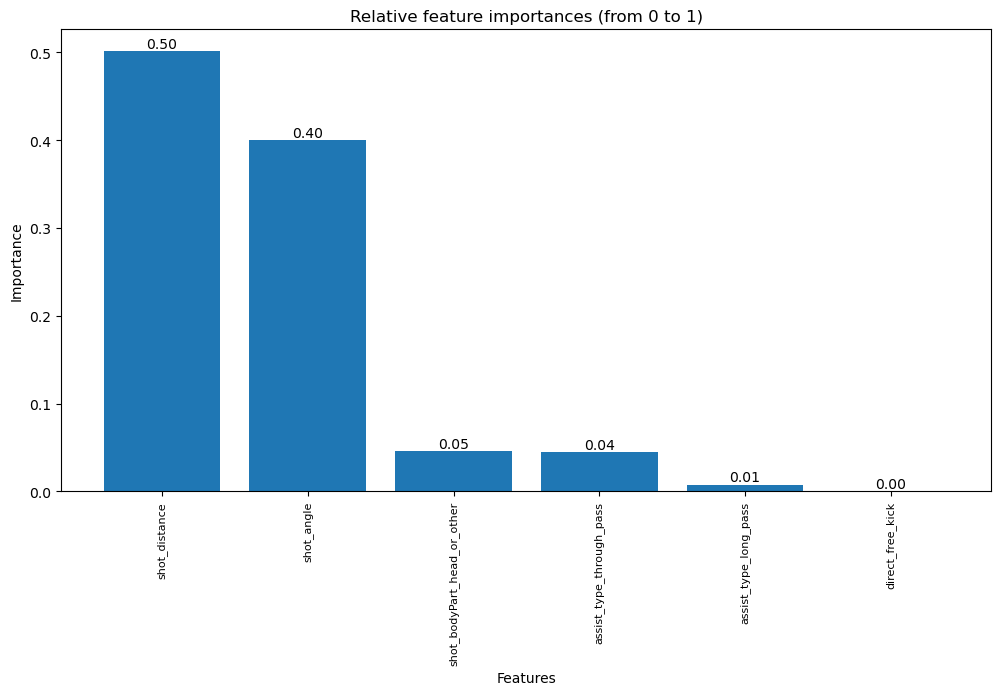

In [ ]:
importances = model_RF.feature_importances_

indexes = np.argsort(importances)[::-1]
sorted_imp = importances[indexes]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(importances)), importances[indexes], align='center')
plt.xticks(range(len(importances)), np.array(model_RF.feature_names_in_)[indexes], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90, fontsize=8)
plt.title("Relative feature importances (from 0 to 1)")
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{sorted_imp[i]:.2f}', ha='center', va='bottom')
plt.show()

## 2. With tracking data

In [ ]:
df_with_tracking= df[["R","goal_angle","assist_type_through_pass","assist_type_long_pass",
                      "shot_bodyPart_head_or_other","direct_free_kick","DDI","shot_isGoal"]]
df_with_tracking.head()

,R,goal_angle,assist_type_through_pass,assist_type_long_pass,shot_bodyPart_head_or_other,direct_free_kick,DDI,shot_isGoal
0,24.624803,16.587813,0,0,0,0,0,0
1,12.127209,14.517517,1,0,0,0,0,0
2,13.676728,10.447233,0,0,0,0,0,0
3,12.396290,5.462242,0,0,1,0,1,0
4,6.845144,33.318625,0,0,1,0,0,0


In [ ]:
y = df_with_tracking["shot_isGoal"]
x= df_with_tracking.drop(columns="shot_isGoal")

# cross validation (80%-20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
print ("Sample size train dataset: ", x_train.shape)
print ("Sample size test dataset: ", x_test.shape)

Sample size train dataset:  (4531, 7)
Sample size test dataset:  (1133, 7)


In [ ]:
param_grid = {
    'n_estimators': [100],  # Keep fixed unless tuning for training time
    'max_features': ['sqrt', 2, 3],
    'min_samples_leaf': [10, 20, 30],
    'max_depth': [None, 5, 7],
    'criterion': ['log_loss']  # fixed for calibrated xG model
}

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define base model
baseRF = RandomForestClassifier(
    random_state=0,
    oob_score=True,
    n_jobs=-1
)

# Grid search
grid = GridSearchCV(
    estimator=baseRF,
    param_grid=param_grid,
    scoring='neg_log_loss',  # or 'roc_auc'
    cv=5,
    verbose=1  # shows progress
)

# Fit model
grid.fit(x_train, y_train)

# Best model
print("✅ Best Parameters:", grid.best_params_)
print("📉 Best Log Loss: {:.4f}".format(-grid.best_score_))


Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Parameters: {'criterion': 'log_loss', 'max_depth': 7, 'max_features': 3, 'min_samples_leaf': 30, 'n_estimators': 100}
📉 Best Log Loss: 0.3403


In [ ]:
# Random Forest
model_RF = RandomForestClassifier(n_estimators = 100, 
                               random_state = 0,
                               max_features = 3, #this parameter makes the difference between simple Bagging and Random Forests
                               n_jobs = -1,
                               oob_score = True,
                               criterion = 'log_loss',
                               min_samples_leaf = 30,
                               max_depth=7)
model_RF.fit(x_train,y_train)

# predictions
y_pred_test = model_RF.predict(x_test)

print("OOB score: {:.2%}".format(model_RF.oob_score_))

OOB score: 88.08%


In [ ]:
from sklearn.metrics import roc_auc_score, log_loss

# --- Training Set ---
pred_prob_train = model_RF.predict_proba(x_train)
prob_train = [p[1] for p in pred_prob_train]

auc_train = roc_auc_score(y_train, prob_train)
logloss_train = log_loss(y_train, prob_train)

print("Training Set Metrics:")
print("ROC AUC score: {:.2%}".format(auc_train))
print("Log Loss: {:.4f}".format(logloss_train))
print("")

# --- Test Set ---
pred_prob_test = model_RF.predict_proba(x_test)
prob_test = [p[1] for p in pred_prob_test]

auc_test = roc_auc_score(y_test, prob_test)
logloss_test = log_loss(y_test, prob_test)

print("Test Set Metrics:")
print("ROC AUC score: {:.2%}".format(auc_test))
print("Log Loss: {:.4f}".format(logloss_test))



Training Set Metrics:
ROC AUC score: 74.94%
Log Loss: 0.3247

Test Set Metrics:
ROC AUC score: 72.13%
Log Loss: 0.3291


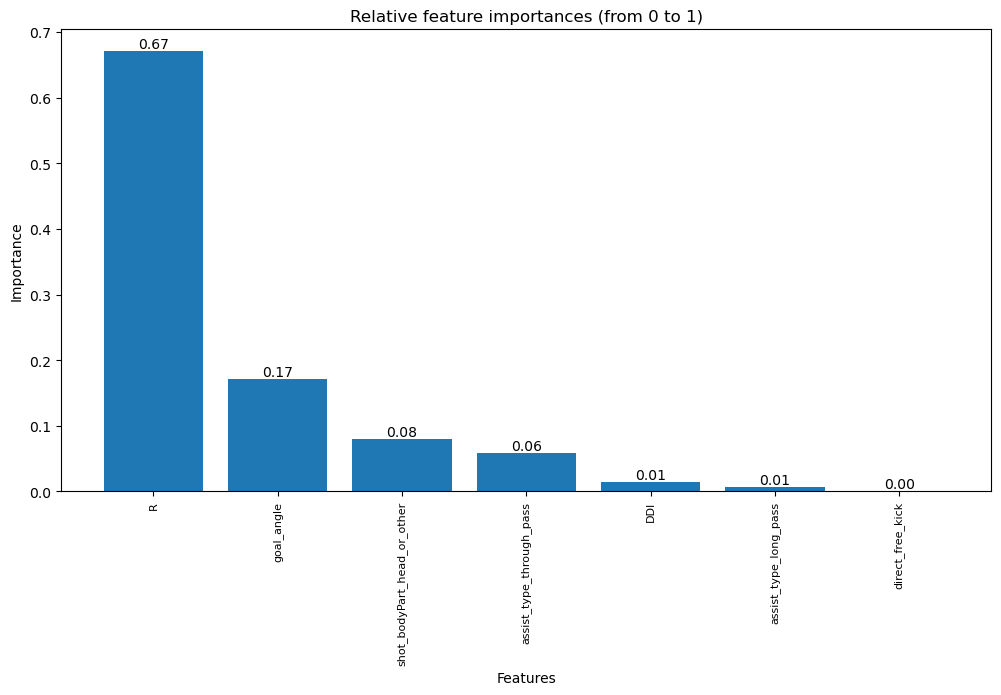

In [ ]:
importances = model_RF.feature_importances_

indexes = np.argsort(importances)[::-1]
sorted_imp = importances[indexes]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(importances)), importances[indexes], align='center')
plt.xticks(range(len(importances)), np.array(model_RF.feature_names_in_)[indexes], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90, fontsize=8)
plt.title("Relative feature importances (from 0 to 1)")
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{sorted_imp[i]:.2f}', ha='center', va='bottom')
plt.show()

In [ ]:
#Try all the players inside the cone (and rivals)
#XGboost
#Metric to be optimized 
#Add new variables

#Insert best result in ppt


In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)  # create folder if it doesn't exist
joblib.dump(model_RF, "models/random_forest_model.pkl")